<font size=8> Chapter 7: Dynamic Programming </font>

In [6]:
# Bottom-Up
def solve_dp(n, capacity):
    # 1. Initialize DP Table (e.g., 1D or 2D array)
    # Use a default value like 0, -1, or float('inf')
    dp = [0] * (n + 1)
    dp = [[0 for _ in range(cols)] for _ in range(rows)]
    
    # 2. Set Base Cases
    dp[0] = base_value
    
    # 3. Iterate through all states
    for i in range(1, n + 1):
        # State Transition Relation
        # Example: dp[i] = max(dp[i-1] + val, dp[i-2])
        dp[i] = compute_from_previous_states(dp[i-1], dp[i-2], ...)
        
    return dp[n]

In [4]:
cols = 2
rows = 3
dp = [[0 for _ in range(cols)] for _ in range(rows)]

In [5]:
dp

[[0, 0], [0, 0], [0, 0]]

# Leetcode 1137. N-th Tribonacci Number

Description:
The Tribonacci sequence Tn is defined as follows:

T0 = 0, T1 = 1, T2 = 1, and Tn+3 = Tn + Tn+1 + Tn+2 for n >= 0.Given n, return the value of Tn.

- Example:

Input: n = 4

Output: 4

Explanation:

T_3 = 0 + 1 + 1 = 2

T_4 = 1 + 1 + 2 = 4

- Example:

Input: n = 25

Output: 1389537

In [13]:
def tribonacci(n):
    if n == 0:
        return 0
    elif n == 1:
        return 1
    elif n == 2:
        return 1
    dp = [0] * (n+1)
    dp[0], dp[1], dp[2]=0, 1, 1
    for i in range(3, n+1):
        dp[i] = dp[i-3] + dp[i-2] + dp[i-1]
    return dp[n]

In [15]:
tribonacci(25)

1389537

In [ ]:
def tribonacci(num):
    if num == 0:
        return 0
    elif num == 1:
        return 1
    elif num == 2:
        return 1
    a, b, c = 0, 1, 1
    for i in range(3, num+1):
        a, b, c = b, c, a+b+c
    return c

# Leetcode 70. Climbing Stairs

You are climbing a stair case. It takes n steps to reach to the top.

Each time you can either climb 1 or 2 steps. 
In how many distinct ways can you climb to the top?

- Example 1:
Input: 2
Output: 2

Explanation:
1. 1 step + 1 step
2. 2 steps

- Example 2:
Input: 3
Output: 3

Explanation:
1. 1 step + 1 step + 1 step
2. 1 step + 2 steps
3. 2 steps + 1 step

In [18]:
def climbStairs(n):
    if n == 1:
        return 1
    if n == 2:
        return 2
    
    dp = [0] * (n+1)
    dp[1], dp[2] = 1, 2
    for i in range(3, n+1):
        dp[i] = dp[i-1] + dp[i-2]
    return dp[n]
    

In [19]:
climbStairs(3)

3

# Leetcode 746. Min Cost Climbing Stairs
Description:
On a staircase, the i-th step has some non-negative cost cost[i] assigned (0 indexed).

Once you pay the cost, you can either climb one or two steps. 
You need to find minimum cost to reach the top of the floor, 
and you can either start from the step with index 0, or the step with index 1.

- Note:

1.cost will have a length in the range [2, 1000].

2.Every cost[i] will be an integer in the range [0, 999].

- Example 1:

Input: cost = [10, 15, 20]

Output: 15

Explanation:
Cheapest is start on cost[1], pay that cost and go to the top.

- Example 2:

Input: cost = [1, 100, 1, 1, 1, 100, 1, 1, 100, 1]

Output: 6

Explanation:
Cheapest is start on cost[0], and only step on 1s, skipping cost[3].

In [51]:
def minCostStairs(nums):
    n = len(nums)
    dp = [0] * (n)
    dp[0], dp[1] = nums[0], nums[1]
    for i in range(2, n):
        dp[i] = min(dp[i-2]+nums[i], dp[i-1] + nums[i])
    return min(dp[n-1], dp[n-2])

In [53]:
minCostStairs([10, 15, 20])

15

In [54]:
minCostStairs([1, 100, 1, 1, 1, 100, 1, 1, 100, 1])

6

# Leetcode 121. Best Time to Buy and Sell Stock

Description:
Say you have an array for which the ith element is the price of a given stock on day i.

If you were only permitted to complete at most one transaction (i.e., buy one and sell one share of the stock), design an algorithm to find the maximum profit.

Note that you cannot sell a stock before you buy one.

- Example 1:
Input: [7,1,5,3,6,4]

Output: 5

Explanation:
Buy on day 2 (price = 1) and sell on day 5 (price = 6), profit = 6-1 = 5.

Not 7-1 = 6, as selling price needs to be larger than buying price.

- Example 2:
Input: [7,6,4,3,1]

Output: 0

Explanation:
In this case, no transaction is done, i.e. max profit = 0.

In [24]:
def bestTimeStock(nums):
    n = len(nums)
    dp = [0] * (n)
    for i in range(1, n):
        dp[i] = max(dp[i-1], nums[i]-min(nums[:i]))
    return dp[n-1]

In [26]:
bestTimeStock([7,1,5,3,6,4])

5

In [27]:
bestTimeStock([7,6,4,3,1])

0

# Leetcode 122. Best Time to Buy and Sell Stock II (Medium)

Description:
Say you have an array prices for which the ith element is the price of a given stock on day i.

Design an algorithm to find the maximum profit. You may complete as many transactions as you like (i.e., buy one and sell one share of the stock multiple times).

Note:
You may not engage in multiple transactions at the same time (i.e., you must sell the stock before you buy again).

Example 1:
Input: [7,1,5,3,6,4]
Output: 7

Explanation:
Buy on day 2 (price = 1) and sell on day 3 (price = 5), profit = 5-1 = 4.
Then buy on day 4 (price = 3) and sell on day 5 (price = 6), profit = 6-3 = 3.

Example 2:
Input: [1,2,3,4,5]
Output: 4

Explanation:
Buy on day 1 (price = 1) and sell on day 5 (price = 5), profit = 5-1 = 4.
Note that you cannot buy on day 1, buy on day 2 and sell them later, as you are
engaging multiple transactions at the same time. You must sell before buying again.

Example 3:
Input: [7,6,4,3,1]
Output: 0

Explanation:
In this case, no transaction is done, i.e. max profit = 0.

In [ ]:
# print(bestTimeStock2([7,1,5,3,6,4]))
# print(bestTimeStock2([1,2,3,4,5]))

# Leetcode 123. Best Time to Buy and Sell Stock III (Hard)

You are given an array prices where prices[i] is the price of a given stock on the ith day.

Find the maximum profit you can achieve. You may complete at most two transactions.

Note: You may not engage in multiple transactions simultaneously (i.e., you must sell the stock before you buy again).

- Example 1:

Input: prices = [3,3,5,0,0,3,1,4]
Output: 6
Explanation: Buy on day 4 (price = 0) and sell on day 6 (price = 3), profit = 3-0 = 3.
Then buy on day 7 (price = 1) and sell on day 8 (price = 4), profit = 4-1 = 3.

- Example 2:

Input: prices = [1,2,3,4,5]
Output: 4
Explanation: Buy on day 1 (price = 1) and sell on day 5 (price = 5), profit = 5-1 = 4.
Note that you cannot buy on day 1, buy on day 2 and sell them later, as you are engaging multiple transactions at the same time. You must sell before buying again.

- Example 3:

Input: prices = [7,6,4,3,1]
Output: 0
Explanation: In this case, no transaction is done, i.e. max profit = 0.

# Leetcode 309. Best Time to Buy and Sell Stock with Cooldown 

Description:
Say you have an array for which the ith element is the price of a given stock on day i.

Design an algorithm to find the maximum profit. You may complete as many transactions as you like 
(ie, buy one and sell one share of the stock multiple times) with the following restrictions:

You may not engage in multiple transactions at the same time (ie, you must sell the stock before you buy again).
After you sell your stock, you cannot buy stock on next day. (ie, cooldown 1 day)

- Example :
Input: [1,2,3,0,2]

Output: 3

Explanation:
transactions = [buy, sell, cooldown, buy, sell]

- Example 2:

Input: prices = [1]
Output: 0

In [14]:
def bestTimeStockCooldown(nums):
    n = len(nums)
    dp = [[0 for _ in range(2)] for _ in range(n)]
    dp[0][0] = 0
    dp[0][1] = -nums[0]
    if n >= 2:
        dp[1][0] = dp[0][1] + nums[1]
        dp[1][1] = dp[0][0] - nums[1]
        for i in range(2, n):
            dp[i][0] = max(dp[i-1][0], dp[i-1][1]+nums[i])
            dp[i][1] = max(dp[i-1][1], dp[i-2][0]-nums[i])
    return dp[n-1][0]

In [15]:
bestTimeStockCooldown([1,2,3,0,2])

3

In [16]:
bestTimeStockCooldown([1])

0

# Leetcode 714. Best Time to Buy and Sell Stock with Transaction Fee (Medium)

Description:
Your are given an array of integers prices, for which the i-th element is the price of a given stock on day i; 
and a non-negative integer fee representing a transaction fee.
You may complete as many transactions as you like, but you need to pay the transaction fee for each transaction. 
You may not buy more than 1 share of a stock at a time (ie. you must sell the stock share before you buy again.)
Return the maximum profit you can make.

Note:
0 < prices.length <= 50000.
0 < prices[i] < 50000.
0 <= fee < 50000.
Example 1:
Input: prices = [1, 3, 2, 8, 4, 9], fee = 2

Output: 8

Explanation:
The maximum profit can be achieved by:

Buying at prices[0] = 1
Selling at prices[3] = 8
Buying at prices[4] = 4
Selling at prices[5] = 9
The total profit is ((8 - 1) - 2) + ((9 - 4) - 2) = 8.

In [ ]:
bestTimeStockFee([1, 3, 2, 8, 4, 9],2)

# Leetcode 53. Maximum Subarray

Description:
Given an integer array nums, find the contiguous subarray (containing at least one number) 
which has the largest sum and return its sum.

- Example:
Input: [-2,1,-3,4,-1,2,1,-5,4],
Output: 6

Explanation:
[4,-1,2,1] has the largest sum = 6.

- Example 2:
Input: nums = [1] Output: 1

Explanation: The subarray [1] has the largest sum 1.

- Example 3:

Input: nums = [5,4,-1,7,8]
Output: 23

Explanation: The subarray [5,4,-1,7,8] has the largest sum 23.

In [40]:
def maxSubarray(nums):
    n = len(nums)
    dp = [0] * n    
    for i in range(n):
       dp[i] = max(dp[i-1]+nums[i], nums[i])
    #print(dp)
    return max(dp)

In [41]:
maxSubarray([-2,1,-3,4,-1,2,1,-5,4])

6

In [36]:
maxSubarray([1])

1

In [37]:
maxSubarray([5,4,-1,7,8])

23

# Leetcode 338. Counting Bits

Given an integer n, return an array ans of length n + 1 such that for each i (0 <= i <= n), ans[i] is the number of 1's in the binary representation of i.

- Example 1:

Input: n = 2
Output: [0,1,1]
Explanation:
0 --> 0
1 --> 1
2 --> 10
- Example 2:

Input: n = 5
Output: [0,1,1,2,1,2]
Explanation:
0 --> 0
1 --> 1
2 --> 10
3 --> 11
4 --> 100
5 --> 101

# Leetcode 392. Is Subsequence

Given two strings s and t, return true if s is a subsequence of t, or false otherwise.

A subsequence of a string is a new string that is formed from the original string by deleting some (can be none) of the characters without disturbing the relative positions of the remaining characters. (i.e., "ace" is a subsequence of "abcde" while "aec" is not).

Example 1:

Input: s = "abc", t = "ahbgdc"
Output: true
Example 2:

Input: s = "axc", t = "ahbgdc"
Output: false

# Leetcode 942. DI String Match

A permutation perm of n + 1 integers of all the integers in the range [0, n] can be represented as a string s of length n where:

s[i] == 'I' if perm[i] < perm[i + 1], and
s[i] == 'D' if perm[i] > perm[i + 1].
Given a string s, reconstruct the permutation perm and return it. If there are multiple valid permutations perm, return any of them.

- Example 1:

Input: s = "IDID"
Output: [0,4,1,3,2]
- Example 2:

Input: s = "III"
Output: [0,1,2,3]
- Example 3:

Input: s = "DDI"
Output: [3,2,0,1]

# Leetcode 1025. Divisor Game

Alice and Bob take turns playing a game, with Alice starting first.

Initially, there is a number n on the chalkboard. On each player's turn, that player makes a move consisting of:

Choosing any integer x with 0 < x < n and n % x == 0.
Replacing the number n on the chalkboard with n - x.
Also, if a player cannot make a move, they lose the game.

Return true if and only if Alice wins the game, assuming both players play optimally.

- Example 1:

Input: n = 2
Output: true
Explanation: Alice chooses 1, and Bob has no more moves.

- Example 2:

Input: n = 3
Output: false
Explanation: Alice chooses 1, Bob chooses 1, and Alice has no more moves.

# Leetcode 152. Maximum Product Subarray (Medium)

Given an integer array nums, find a subarray that has the largest product, and return the product.

The test cases are generated so that the answer will fit in a 32-bit integer.

Note that the product of an array with a single element is the value of that element.

- Example 1:

Input: nums = [2,3,-2,4]
Output: 6
Explanation: [2,3] has the largest product 6.

- Example 2:

Input: nums = [-2,0,-1]
Output: 0
Explanation: The result cannot be 2, because [-2,-1] is not a subarray.

Constraints:

1 <= nums.length <= 2 * 104
-10 <= nums[i] <= 10
The product of any subarray of nums is guaranteed to fit in a 32-bit integer.

# Leetcode 62. Unique Paths

Description:
A robot is located at the top-left corner of a m x n grid (marked "Start" in the diagram below).

The robot can only move either down or right at any point in time. The robot is trying to reach the bottom-right corner of the grid (marked "Finish" in the diagram below).

How many possible unique paths are there?

- Example 1:
  
Input: m = 3, n = 2

Output: 3

Explanation:
From the top-left corner, there are a total of 3 ways to reach the bottom-right corner:

1. Right -> Right -> Down

2. Right -> Down -> Right

3. Down -> Right -> Right

- Example 2:
Input: m = 7, n = 3

Output: 28

Constraints:
1 <= m, n <= 100
It’s guaranteed that the answer will be less than or equal to 2 * 10 ^ 9.

In [ ]:
uniquePaths(3,2)

# Leetcode 63. Unique Paths II (Medium)

You are given an m x n integer array grid. There is a robot initially located at the top-left corner (i.e., grid[0][0]). The robot tries to move to the bottom-right corner (i.e., grid[m - 1][n - 1]). The robot can only move either down or right at any point in time.

An obstacle and space are marked as 1 or 0 respectively in grid. A path that the robot takes cannot include any square that is an obstacle.

Return the number of possible unique paths that the robot can take to reach the bottom-right corner.

The testcases are generated so that the answer will be less than or equal to 2 * 109.

- Example 1:

Input: obstacleGrid = [[0,0,0],[0,1,0],[0,0,0]]
Output: 2
Explanation: There is one obstacle in the middle of the 3x3 grid above.
There are two ways to reach the bottom-right corner:
1. Right -> Right -> Down -> Down
2. Down -> Down -> Right -> Right

- Example 2:

Input: obstacleGrid = [[0,1],[0,0]]
Output: 1

Constraints:

m == obstacleGrid.length
n == obstacleGrid[i].length
1 <= m, n <= 100
obstacleGrid[i][j] is 0 or 1.

# Leetcode 64. Minimum Path Sum (Medium)

Given a m x n grid filled with non-negative numbers, find a path from top left to bottom right, which minimizes the sum of all numbers along its path.

Note: You can only move either down or right at any point in time.

- Example 1:

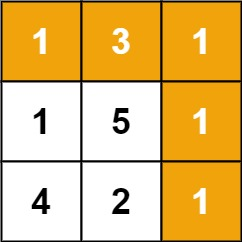

Input: grid = [[1,3,1],[1,5,1],[4,2,1]]
Output: 7
Explanation: Because the path 1 → 3 → 1 → 1 → 1 minimizes the sum.

- Example 2:

Input: grid = [[1,2,3],[4,5,6]]
Output: 12

# Leetcode 198. House Robber

Description:
You are a professional robber planning to rob houses along a street. 
Each house has a certain amount of money stashed, the only constraint ,

stopping you from robbing each of them is that adjacent houses have security system connected 
and it will automatically contact the police ,
if two adjacent houses were broken into on the same night.

Given a list of non-negative integers representing the amount of money of each house, 
determine the maximum amount of money you can rob tonight without alerting the police.

Example 1:
Input: nums = [1,2,3,1]
Output: 4

Explanation:
Rob house 1 (money = 1) and then rob house 3 (money = 3).

Total amount you can rob = 1 + 3 = 4.

Example 2:
Input: nums = [2,7,9,3,1]
Output: 12

Explanation:
Rob house 1 (money = 2), rob house 3 (money = 9) and rob house 5 (money = 1).
Total amount you can rob = 2 + 9 + 1 = 12.

Constraints:
0 <= nums.length <= 100
0 <= nums[i] <= 400

In [31]:
def houseRobber(nums):
    n = len(nums)
    dp = [0] * n
    dp[0], dp[1] = nums[0], nums[1]    
    for i in range(2, n):
        dp[i] = max(dp[i-1], dp[i-2] + nums[i])
    return dp[n-1]

In [32]:
houseRobber([1,2,3,1])

4

In [33]:
houseRobber([2,7,9,3,1])

12

# Leetcode 213. House Robber II

Description:
You are a professional robber planning to rob houses along a street. Each house has a certain amount of money stashed. 
All houses at this place are arranged in a circle.

That means the first house is the neighbor of the last one. 
Meanwhile, adjacent houses have security system connected and it will automatically contact the police if two adjacent houses were broken into on the same night.

Given a list of non-negative integers representing the amount of money of each house, 
determine the maximum amount of money you can rob tonight without alerting the police.

Example 1:
Input: [2,3,2]
Output: 3

Explanation:
You cannot rob house 1 (money = 2) and then rob house 3 (money = 2),because they are adjacent houses.

Example 2:
Input: [1,2,3,1]
Output: 4

Explanation:
Rob house 1 (money = 1) and then rob house 3 (money = 3).
Total amount you can rob = 1 + 3 = 4.

In [ ]:
def houseRobber2(nums):
    

In [ ]:
houseRobber2([2,3,2])

In [ ]:
houseRobber2([1,2,3,1])

In [ ]:
houseRobber2([1,2,3])

# Leetcode 72. Edit Distance (Medium)

Given two strings word1 and word2, return the minimum number of operations required to convert word1 to word2.

You have the following three operations permitted on a word:

Insert a character
Delete a character
Replace a character

- Example 1:

Input: word1 = "horse", word2 = "ros"
Output: 3

Explanation: 
horse -> rorse (replace 'h' with 'r')
rorse -> rose (remove 'r')
rose -> ros (remove 'e')

- Example 2:

Input: word1 = "intention", word2 = "execution"
Output: 5

Explanation: 
intention -> inention (remove 't')
inention -> enention (replace 'i' with 'e')
enention -> exention (replace 'n' with 'x')
exention -> exection (replace 'n' with 'c')
exection -> execution (insert 'u')

# Leetcode 91. Decode Ways (Medium)

You have intercepted a secret message encoded as a string of numbers. The message is decoded via the following mapping:

"1" -> 'A'

"2" -> 'B'

...

"25" -> 'Y'

"26" -> 'Z'

However, while decoding the message, you realize that there are many different ways you can decode the message because some codes are contained in other codes ("2" and "5" vs "25").

For example, "11106" can be decoded into:

"AAJF" with the grouping (1, 1, 10, 6)
"KJF" with the grouping (11, 10, 6)
The grouping (1, 11, 06) is invalid because "06" is not a valid code (only "6" is valid).
Note: there may be strings that are impossible to decode.

Given a string s containing only digits, return the number of ways to decode it. If the entire string cannot be decoded in any valid way, return 0.

The test cases are generated so that the answer fits in a 32-bit integer.


- Example 1:

Input: s = "12"

Output: 2

Explanation:

"12" could be decoded as "AB" (1 2) or "L" (12).

- Example 2:

Input: s = "226"

Output: 3

Explanation:

"226" could be decoded as "BZ" (2 26), "VF" (22 6), or "BBF" (2 2 6).

- Example 3:

Input: s = "06"

Output: 0

Explanation:

"06" cannot be mapped to "F" because of the leading zero ("6" is different from "06"). In this case, the string is not a valid encoding, so return 0.

# Leetcode 96. Unique Binary Search Trees (Medium)

Given an integer n, return the number of structurally unique BST's (binary search trees) which has exactly n nodes of unique values from 1 to n.


- Example 1:

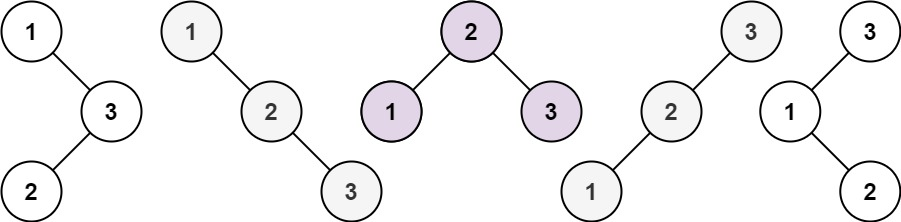

Input: n = 3
Output: 5
Example 2:

Input: n = 1
Output: 1

# Leetcode 95. Unique Binary Search Trees II (Medium)

Given an integer n, return all the structurally unique BST's (binary search trees), which has exactly n nodes of unique values from 1 to n. Return the answer in any order.

- Example 1:


Input: n = 3
Output: [[1,null,2,null,3],[1,null,3,2],[2,1,3],[3,1,null,null,2],[3,2,null,1]]
- Example 2:

Input: n = 1
Output: [[1]]

# Leetcode 97. Interleaving String (Medium)

Given strings s1, s2, and s3, find whether s3 is formed by an interleaving of s1 and s2.

An interleaving of two strings s and t is a configuration where s and t are divided into n and m substrings respectively, such that:

s = s1 + s2 + ... + sn
t = t1 + t2 + ... + tm
|n - m| <= 1
The interleaving is s1 + t1 + s2 + t2 + s3 + t3 + ... or t1 + s1 + t2 + s2 + t3 + s3 + ...
Note: a + b is the concatenation of strings a and b.

- Example 1:

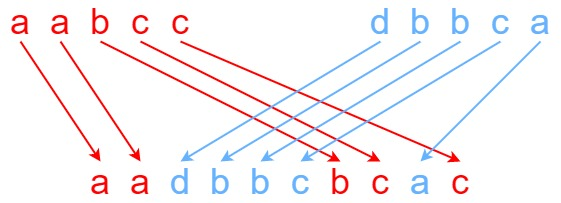

Input: s1 = "aabcc", s2 = "dbbca", s3 = "aadbbcbcac"
Output: true

Explanation: One way to obtain s3 is:
Split s1 into s1 = "aa" + "bc" + "c", and s2 into s2 = "dbbc" + "a".
Interleaving the two splits, we get "aa" + "dbbc" + "bc" + "a" + "c" = "aadbbcbcac".
Since s3 can be obtained by interleaving s1 and s2, we return true.

- Example 2:

Input: s1 = "aabcc", s2 = "dbbca", s3 = "aadbbbaccc"
Output: false

Explanation: Notice how it is impossible to interleave s2 with any other string to obtain s3.

- Example 3:

Input: s1 = "", s2 = "", s3 = ""
Output: true

# Leetcode 120. Triangle (Medium)

Given a triangle array, return the minimum path sum from top to bottom.

For each step, you may move to an adjacent number of the row below. More formally, if you are on index i on the current row, you may move to either index i or index i + 1 on the next row.

- Example 1:

Input: triangle = [[2],[3,4],[6,5,7],[4,1,8,3]]
Output: 11
Explanation: The triangle looks like:
   2
  3 4
 6 5 7
4 1 8 3
The minimum path sum from top to bottom is 2 + 3 + 5 + 1 = 11 (underlined above).
- Example 2:

Input: triangle = [[-10]]
Output: -10

# Leetcode 139. Word Break (Medium)

Given a string s and a dictionary of strings wordDict, return true if s can be segmented into a space-separated sequence of one or more dictionary words.

Note that the same word in the dictionary may be reused multiple times in the segmentation.

- Example 1:

Input: s = "leetcode", wordDict = ["leet","code"]
Output: true
Explanation: Return true because "leetcode" can be segmented as "leet code".
- Example 2:

Input: s = "applepenapple", wordDict = ["apple","pen"]
Output: true
Explanation: Return true because "applepenapple" can be segmented as "apple pen apple".
Note that you are allowed to reuse a dictionary word.
- Example 3:

Input: s = "catsandog", wordDict = ["cats","dog","sand","and","cat"]
Output: false

# Leetcode 140. Word Break II (Hard)

Given a string s and a dictionary of strings wordDict, add spaces in s to construct a sentence where each word is a valid dictionary word. Return all such possible sentences in any order.

Note that the same word in the dictionary may be reused multiple times in the segmentation.

- Example 1:

Input: s = "catsanddog", wordDict = ["cat","cats","and","sand","dog"]
Output: ["cats and dog","cat sand dog"]

- Example 2:

Input: s = "pineapplepenapple", wordDict = ["apple","pen","applepen","pine","pineapple"]
Output: ["pine apple pen apple","pineapple pen apple","pine applepen apple"]
Explanation: Note that you are allowed to reuse a dictionary word.

- Example 3:

Input: s = "catsandog", wordDict = ["cats","dog","sand","and","cat"]
Output: []

# Leetcode 279. Perfect Squares (Medium)
Given an integer n, return the least number of perfect square numbers that sum to n.

A perfect square is an integer that is the square of an integer; in other words, it is the product of some integer with itself. For example, 1, 4, 9, and 16 are perfect squares while 3 and 11 are not.


- Example 1:

Input: n = 12
Output: 3
Explanation: 12 = 4 + 4 + 4.

- Example 2:

Input: n = 13
Output: 2
Explanation: 13 = 4 + 9.

# Leetcode 300. Longest Increasing Subsequence (Medium)

Given an integer array nums, return the length of the longest strictly increasing subsequence.

- Example 1:

Input: nums = [10,9,2,5,3,7,101,18]
Output: 4
Explanation: The longest increasing subsequence is [2,3,7,101], therefore the length is 4.
- Example 2:

Input: nums = [0,1,0,3,2,3]
Output: 4
- Example 3:

Input: nums = [7,7,7,7,7,7,7]
Output: 1

# Leetcode 322. Coin Change (Medium)

You are given an integer array coins representing coins of different denominations and an integer amount representing a total amount of money.

Return the fewest number of coins that you need to make up that amount. If that amount of money cannot be made up by any combination of the coins, return -1.

You may assume that you have an infinite number of each kind of coin.


- Example 1:

Input: coins = [1,2,5], amount = 11
Output: 3
Explanation: 11 = 5 + 5 + 1
- Example 2:

Input: coins = [2], amount = 3
Output: -1
- Example 3:

Input: coins = [1], amount = 0
Output: 0

# Leetcode 343. Integer Break (Medium)

Given an integer n, break it into the sum of k positive integers, where k >= 2, and maximize the product of those integers.

Return the maximum product you can get.

- Example 1:

Input: n = 2
Output: 1
Explanation: 2 = 1 + 1, 1 × 1 = 1.
- Example 2:

Input: n = 10
Output: 36
Explanation: 10 = 3 + 3 + 4, 3 × 3 × 4 = 36.

# Leetcode 357. Count Numbers with Unique Digits (Medium)

Given an integer n, return the count of all numbers with unique digits, x, where 0 <= x < 10n.

- Example 1:

Input: n = 2
Output: 91
Explanation: The answer should be the total numbers in the range of 0 ≤ x < 100, excluding 11,22,33,44,55,66,77,88,99

- Example 2:

Input: n = 0
Output: 1

# Leetcode 416. Partition Equal Subset Sum (Medium)

Given an integer array nums, return true if you can partition the array into two subsets such that the sum of the elements in both subsets is equal or false otherwise.

- Example 1:

Input: nums = [1,5,11,5]
Output: true
Explanation: The array can be partitioned as [1, 5, 5] and [11].
- Example 2:

Input: nums = [1,2,3,5]
Output: false
Explanation: The array cannot be partitioned into equal sum subsets.

# Leetcode 1480. Running Sum of 1d Array

Description:
Given an array nums. We define a running sum of an array as runningSum[i] = sum(nums[0]…nums[i]).

Return the running sum of nums.

- Example 1:
Input: nums = [1,2,3,4]

Output: [1,3,6,10]

Explanation:
Running sum is obtained as follows: [1, 1+2, 1+2+3, 1+2+3+4].

- Example 2:
Input: nums = [1,1,1,1,1]

Output: [1,2,3,4,5]

Explanation:
Running sum is obtained as follows: [1, 1+1, 1+1+1, 1+1+1+1, 1+1+1+1+1].

- Example 3:
Input: nums = [3,1,2,10,1]

Output: [3,4,6,16,17]

Constraints:
1 <= nums.length <= 1000/li>
-10^6 <= nums[i] <= 10^6

In [25]:
def sumArray(nums):
    n = len(nums)
    dp = [0] * (n)
    dp[0] = nums[0]
    for i in range(n):
        dp[i] = dp[i-1] + nums[i]
    return dp

In [26]:
sumArray([3,1,2,10,1])

[3, 4, 6, 16, 17]

# Leetcode 1143. Longest Common Subsequence

Description:
Given two strings text1 and text2, return the length of their longest common subsequence.

A subsequence of a string is a new string generated from the original string with some characters(can be none) deleted without changing the relative order of the remaining characters. (eg, "ace" is a subsequence of "abcde" while "aec" is not). A common subsequence of two strings is a subsequence that is common to both strings.

If there is no common subsequence, return 0.

- Example 1:
Input: text1 = ""abcde"", text2 = "ace"
Output: 3

Explanation:
The longest common subsequence is "ace" and its length is 3.

- Example 2:
Input: text1 = "abc", text2 = "abc"
Output: 3

Explanation:
The longest common subsequence is "abc" and its length is 3.

- Example 3:
Input: text1 = "abc", text2 = "def"
Output: 0

Explanation:
There is no such common subsequence, so the result is 0.

Constraints:
1 <= text1.length <= 1000
1 <= text2.length <= 1000
The input strings consist of lowercase English characters only.

In [20]:
def maxSubString(text1, text2):
    m, n = len(text1), len(text2)
    dp = [[0 for _ in range(n+1)] for _ in range(m+1)]

    for i, a in enumerate(text1, 1):
        for j, b in enumerate(text2, 1):
            if a == b:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1]) 
    return dp[m][n]


In [22]:
maxSubString("abcde", "ace")

3

In [23]:
maxSubString("abc", "abc")

3

In [24]:
maxSubString("abc", "def")

0

# Leetcode 583. Delete Operation for Two Strings

Description:
Given two words word1 and word2, find the minimum number of steps required to make word1 and word2 the same, 
where in each step you can delete one character in either string.

Note:
The length of given words won’t exceed 500.
Characters in given words can only be lower-case letters.

- Example 1:
Input: "sea", "eat"

Output: 2

Explanation:
You need one step to make "sea" to "ea" and another step to make "eat" to "ea".

- Example 2:
Input: nums = word1 = "leetcode", word2 = "etco"

Output: 4

In [17]:
def deleteOpStrings(word1, word2):
    m, n = len(word1), len(word2)
    dp = [[0 for _ in range(n+1)] for _ in range(m+1)]
    for i in range(1, m+1):
        dp[i][0] = i
    for j in range(1, n+1):
        dp[0][j] = j
    for i, a in enumerate(word1, 1):
        for j, b in enumerate(word2, 1):
            if a == b:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(dp[i-1][j], dp[i][j-1]) + 1
    return dp[m][n]

In [18]:
deleteOpStrings("sea","eat")

2

In [19]:
deleteOpStrings("leetcode","etco")

4

# Leetcode 132. Palindrome Partitioning II (Hard)

Given a string s, partition s such that every substring of the partition is a palindrome.
Return the minimum cuts needed for a palindrome partitioning of s.

- Example 1:

Input: s = "aab"
Output: 1
Explanation: The palindrome partitioning ["aa","b"] could be produced using 1 cut.
- Example 2:

Input: s = "a"
Output: 0
- Example 3:

Input: s = "ab"
Output: 1

# Leetcode 85. Maximal Rectangle (Hard)

Given a rows x cols binary matrix filled with 0's and 1's, find the largest rectangle containing only 1's and return its area.

- Example 1:

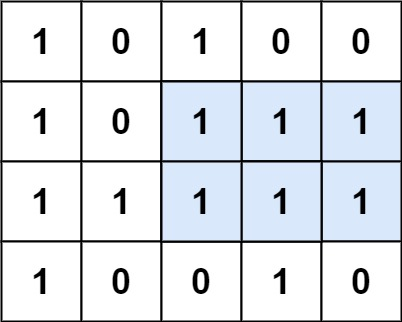

Input: matrix = [["1","0","1","0","0"],["1","0","1","1","1"],["1","1","1","1","1"],["1","0","0","1","0"]]
Output: 6
Explanation: The maximal rectangle is shown in the above picture.

- Example 2:

Input: matrix = [["0"]]
Output: 0

-Example 3:

Input: matrix = [["1"]]
Output: 1

# Leetcode 87. Scramble String (Hard)

We can scramble a string s to get a string t using the following algorithm:

If the length of the string is 1, stop.
If the length of the string is > 1, do the following:
Split the string into two non-empty substrings at a random index, i.e., if the string is s, divide it to x and y where s = x + y.
Randomly decide to swap the two substrings or to keep them in the same order. i.e., after this step, s may become s = x + y or s = y + x.
Apply step 1 recursively on each of the two substrings x and y.
Given two strings s1 and s2 of the same length, return true if s2 is a scrambled string of s1, otherwise, return false.

- Example 1:

Input: s1 = "great", s2 = "rgeat"
Output: true

Explanation: One possible scenario applied on s1 is:
"great" --> "gr/eat" // divide at random index.
"gr/eat" --> "gr/eat" // random decision is not to swap the two substrings and keep them in order.
"gr/eat" --> "g/r / e/at" // apply the same algorithm recursively on both substrings. divide at random index each of them.
"g/r / e/at" --> "r/g / e/at" // random decision was to swap the first substring and to keep the second substring in the same order.
"r/g / e/at" --> "r/g / e/ a/t" // again apply the algorithm recursively, divide "at" to "a/t".
"r/g / e/ a/t" --> "r/g / e/ a/t" // random decision is to keep both substrings in the same order.
The algorithm stops now, and the result string is "rgeat" which is s2.
As one possible scenario led s1 to be scrambled to s2, we return true.

- Example 2:

Input: s1 = "abcde", s2 = "caebd"
Output: false

- Example 3:

Input: s1 = "a", s2 = "a"
Output: true

# Leetcode 115. Distinct Subsequences (Hard)

Given two strings s and t, return the number of distinct subsequences of s which equals t.

The test cases are generated so that the answer fits on a 32-bit signed integ
 

- Example 1:

Input: s = "rabbbit", t = "rabbit"
Output: 3

Explanation:
As shown below, there are 3 ways you can generate "rabbit" from s.
rabbbit
rabbbit
rabbbit

- Example 2:

Input: s = "babgbag", t = "bag"
Output: 5

Explanation:
As shown below, there are 5 ways you can generate "bag" from s.
babgbag
babgbag
babgbag
babgbag
babgbag

# Extra: Coins in a Line

There are n coins in a line. (Assume n is even). Two players take turns to take a coin
from one of the ends of the line until there are no more coins left. The player with the
larger amount of money wins.
1. Would you rather go first or second? Does it matter?
2. Assume that you go first, describe an algorithm to compute the maximum amount
of money you can win.